# Inverse problems experiments
In this notebook you'll familiarize with all the concepts of inverse problems

As an example, we will work with a "deblurring" problem. The concept will be

*i)* Blur an image $\rightarrow$ *ii)* apply a deblurring algorithm

This is what happens with a microscope or a camera, some of the highest frequencies get detected "less" by the detector. And you'll like to make the image as sharp as you can for display

Here, you'll try to do this in an increasingly difficult condition:
1. Ideal setup: apply the blurring, apply the mathematical inverse
2. Less ideal setup: apply the blurring, add a bit of noise (i.e.: what happens in a real world detector!), apply the mathematical inverse
3. Same setup: solve it with iterative algorithms

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fft2, fftfreq

In [16]:
img = np.load('testMR.npy')

# The blurring problem
Blurring can be described as a convolution. Let's assume, for simplicity, that we are dealing with a gaussian kernel. (most cameras will have a more complex setup actually)
Simulate a "small" blurring, something that's realistic to be recovered. Something with a $\sigma \in [.9,2.0]$ should work.
Remember that convolution is a multiplication in the fourier spectrum of the fourier transform of the kernel, therefore deconvolution is just multiplying by the inverse.

**Remember**

$y = K \otimes \lambda $ is equal to $y = F^{-1} \left(F K \times F \lambda \right )$ and also that the fourier transform of a gaussian is still a gaussian: $F\left(exp\left(-\frac{-x^2}{2\sigma^2}\right)\right)=exp\left(-f^2 \pi^2 2\sigma^2 \right)$

Therefore you can implement the convolution this way


Compare this convolution in fourier with ndi.gaussian_filter

In [27]:

xv = fftfreq(img.shape[0])[:, None]

yv = fftfreq(img.shape[1])[:, None]
yv = yv.transpose()

sigma = 1.5  # Sigma in pixel units
gaussK = np.exp(-(xv**2+yv**2)*(np.pi**2*2*sigma**2))

Text(0.5, 1.0, 'Blurred')

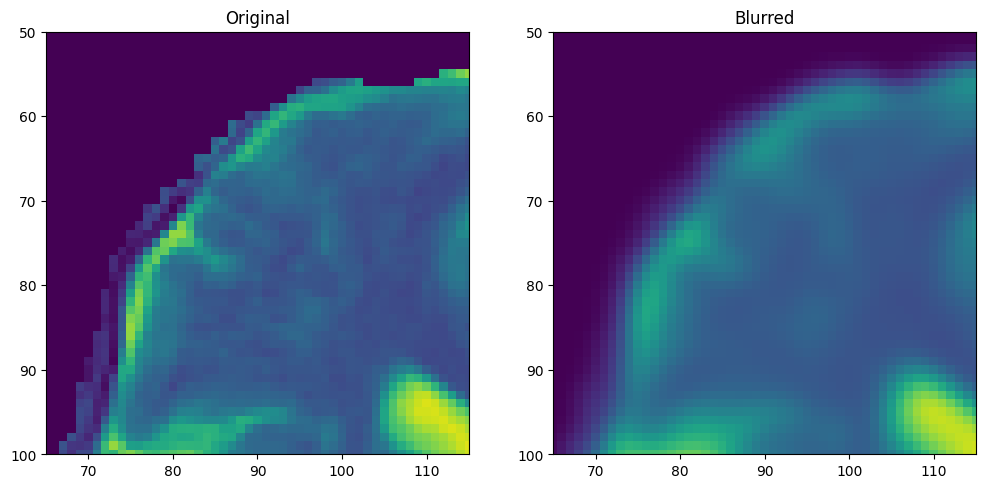

In [28]:
blurred_img = ifft2(fft2(img)*gaussK).real # Convolution theorem in action 


plt.figure(figsize=(12,7))
plt.subplot(121)
plt.imshow(img)
plt.xlim(65,115)
plt.ylim(100,50)
plt.title('Original')
plt.subplot(122)
plt.imshow(blurred_img)
plt.xlim(65,115)
plt.ylim(100,50)
plt.title('Blurred')
# plt.colorbar()

# Task 1: Invert the transform analytically

If the blurring is multiplying in Fourier by a function... You can invert it by multiplying for the inverse
$\lambda_{deblur} = F^{-1} \left(\frac{1}{FK}\times y_{blur} \right)$

(100.0, 50.0)

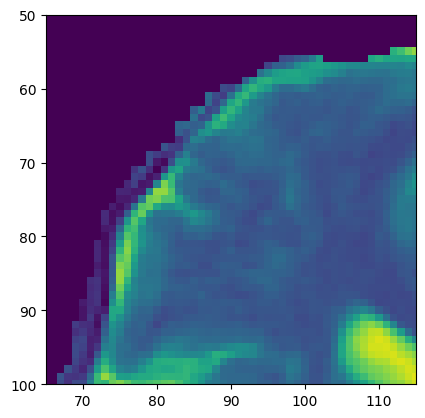

In [ ]:
noi
inverse_blurred_img = ifft2(fft2(blurred_img)/gaussK + ).real

plt.imshow(inverse_blurred_img)
plt.xlim(65,115)
plt.ylim(100,50)

## Task 1.1: What happens in a realistic case?
In a real system $y_{blur} = K\otimes\lambda +\mathcal{N}(0,\varepsilon)$

what happens if you apply this inversion here? Try this as a function of blurring $\sigma$ and noise level $\varepsilon$

**If images don't seem to display think about imshow vmin/vmax**

What's your first fix if this inversion fails? In which cases does it "fail"?

(100.0, 50.0)

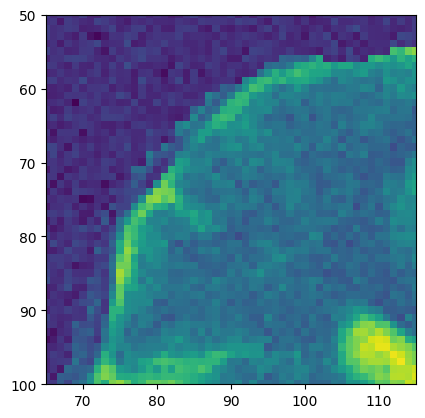

In [ ]:
noise = 15 * np.random.randn(*i1.shape)
iDB = np.fft.ifft2(np.fft.fft2(iB2)/gaussK + noise).real
plt.imshow(iDB)
plt.xlim(65,115)
plt.ylim(100,50)

noise = 15 * np.random.randn(*i1.shape)
iDB = np.fft.ifft2(np.fft.fft2(iB2)/gaussK + noise).real
plt.imshow(iDB)
plt.xlim(65,115)
plt.ylim(100,50)

# Task 2: Implement an iterative reconstruction
The problem you want to solve, assuming normal (i.e.: Gaussian) noise is find the minimum of $\left\lVert Ax-y\right\rVert^2$
Remember the gradient descent iterative optimization algorithm works this way:
Set $x^0=0$; $y^0=0$. The "residual" $r=y-Ax$ is therefore initialized to $y$. The iterative algorithm repeats the following:
1. The gradient is $g = A^T r$
2. Compute the optimal step size: $\alpha= \frac{||g||^2}{||Ag||^2}$
3. Update $x$ with $x^{k+1}=x^k+\alpha g$
4. Update the residual $r^{k+1}=y-Ax^{k+1}$. Since $A$ is linear you can avoid to compute a second time $A$. Indeed $r^{k+1}=y-A^{k}+Ag^k = r^k + \alpha Ag$, so you can reuse $\alpha g$ from the previous step

Details:
* You can monitor your loss by just computing: $\left\lVert r \right \rVert^2 $, after every iteration. Remember that the vast majority of the time is spent computing $Ax$ or $A^T y$. Doing $\left\lVert r \right \rVert^2 $ is very cheap
* Write a function, or a class, that does the reconstruction. Parameters that the user need to set are: starting image (0 or a different initial guess), number of iterations, measured data. This function should return/provide: reconstructed image, loss value.
* In this problem $A$ if the convolution with a gaussian, and $A^T$ is the same operation. Write the previous function in a way that it's trivial to adapt it to all other cases (Radon transform for CT, FFT for MR)
* Experiment with the N° of iterations/stopping criteria

# Task 3: Write the iterative reconstruction algorithm for MR

In this case $A$ is `np.fft.fft2` and $A^T$ is `np.fft.ifft2`. Notice that for FFT $A^T = A^{-1}$, which means that in an iterative algorithm with exact step size you'll converge in one iteration!!

**Notice:** the FFT as implemented by default in `numpy` is such that `ifft` is not the exact transpose of `fft`, because of the "normalization". In the default: $FFT:\; A_k=\sum_{i\in [0,N]} a_m \,exp \left(-2\pi i mk/N\right) $ and  $ IFFT:\; a_m=\frac{1}{N} \sum_{k\in [0,N]} A_k\, exp \left(2\pi i mk/N\right) $

The factor $\frac{1}{N}$ if present only in `ifft`. Set `np.fft.fft2(norm='ortho')` and `np.fft.ifft2(norm='ortho')` so that it applies a factor $\frac{1}{\sqrt{N}}$ in both functions. This way $A^T$ and $A$ are perfectly the transpose. Otherwise the step size computation will be wrong!

# Task 4: Write the iterative reconstruction algorithm for CT

Use a separate notebook if you wish. In this case $A$ is the function `skimage.transform.radon` and $A^T$ is  `skimage.transform.iradon(filter_name='none')`

Notice that also `radon` and `iradon` are unmatched. When computing the step size do: $\frac{\pi}{N_{\theta}} \left\lVert Ag\right\rVert^2$ in the denominator